# AgriSense — Task 2: Weather-Effect Analysis & Image Restoration

| Degradation | Classical Method | Deep Learning Method |
|-------------|-----------------|---------------------|
| **Haze** | Dark Channel Prior (DCP) — NumPy | AOD-Net (PyTorch CNN) |
| **Rain streaks** | FFT Notch Filtering — NumPy | ID-CGAN (simplified PyTorch) |
| **Cloud gaps** | Temporal Median Compositing | Partial-Conv Inpainting (PyTorch) |
| **Fog / Low contrast** | CLAHE per band (OpenCV) | — |

**Metrics reported:** PSNR (dB) · SSIM (0–1) · LPIPS (↓) · Inference time per 256×256 tile (s)

**Input:** `S2_final_stack.tif` from Task 1 (7-band BOA, EPSG:32642)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── CELL 0: Install dependencies ──────────────────────────────────────────────
import subprocess, sys

pkgs = ['lpips', 'torch', 'torchvision', 'scikit-image',
        'opencv-contrib-python', 'matplotlib', 'numpy', 'rasterio', 'pandas']

for pkg in pkgs:
    try:
        imp = pkg.replace('opencv-contrib-python','cv2').replace('-','_')
        __import__(imp)
    except ImportError:
        print(f'Installing {pkg}...')
        subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

print('All dependencies ready.')

Installing lpips...
Installing scikit-image...
All dependencies ready.


In [3]:
# ── CELL 1: Imports & global config ──────────────────────────────────────────
import numpy as np
import cv2
import time
import warnings
import rasterio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim
import torch
import torch.nn as nn
import torch.nn.functional as F
import lpips
warnings.filterwarnings('ignore')

BASE       = Path('.')             # folder with S2_final_stack.tif
TILE_SIZE  = 256                   # rubric: metrics on 256×256 tiles
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

# Band mapping in the 7-band stack
# Index:   0     1      2     3        4     5      6
# Band:   B2    B3     B4    B5       B8    B11    B12
# Name: Blue  Green   Red  RedEdge  NIR   SWIR1  SWIR2
BAND_NAMES = ['B2_Blue','B3_Green','B4_Red','B5_RedEdge','B8_NIR','B11_SWIR1','B12_SWIR2']
B_BLUE, B_GREEN, B_RED, B_RE, B_NIR, B_SWIR1, B_SWIR2 = 0,1,2,3,4,5,6

# Shared LPIPS network (initialised once)
lpips_fn = lpips.LPIPS(net='alex').to(DEVICE)
lpips_fn.eval()

print(f'Device : {DEVICE}')
print(f'Tile   : {TILE_SIZE}×{TILE_SIZE}')
print('Cell 1 OK')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 137MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Device : cpu
Tile   : 256×256
Cell 1 OK


In [5]:
# ── CELL 2: Load Task-1 output & extract a representative tile ───────────────
STACK_PATH = BASE / '/content/drive/MyDrive/AgriSense/S2_final_stack.tif'

with rasterio.open(STACK_PATH) as src:
    full_stack = src.read().astype(np.float32)   # (7, H, W)
    profile    = src.profile.copy()

# Replace nodata (-9999) with NaN, then fill NaN with band median
full_stack = np.where(full_stack == -9999.0, np.nan, full_stack)
for b in range(full_stack.shape[0]):
    med = np.nanmedian(full_stack[b])
    full_stack[b] = np.where(np.isnan(full_stack[b]), med, full_stack[b])

# Auto-scale: if data is DN (max > 1), convert to reflectance
vmax = np.nanmax(full_stack)
if vmax > 2.0:
    full_stack = np.clip(full_stack * 0.0001, 0, 1)
    print(f'Scaled DN→reflectance (was max={vmax:.0f})')
else:
    full_stack = np.clip(full_stack, 0, 1)
    print(f'Data already in [0,1] (max={vmax:.4f})')

H_full, W_full = full_stack.shape[1:]
print(f'Full stack: {full_stack.shape}  [{full_stack.min():.4f}, {full_stack.max():.4f}]')

# ── Extract a central 256×256 tile (spatially representative) ────────────────
# We pick a tile near the centre with the best vegetation signal (highest NDVI)
def extract_best_tile(stack, ts=256, n_candidates=20):
    """Find the 256×256 tile with highest mean NDVI (most information content)."""
    nir = stack[B_NIR]; red = stack[B_RED]
    ndvi_map = np.where((nir+red)>0, (nir-red)/(nir+red+1e-8), 0)
    best_score, best_r, best_c = -1, 0, 0
    step = max(1, (H_full - ts) // n_candidates)
    for r in range(0, H_full - ts, step):
        for c in range(0, W_full - ts, step):
            score = ndvi_map[r:r+ts, c:c+ts].mean()
            if score > best_score:
                best_score, best_r, best_c = score, r, c
    return stack[:, best_r:best_r+ts, best_c:best_c+ts], best_r, best_c

tile_stack, TR, TC = extract_best_tile(full_stack)
print(f'Selected tile: row={TR} col={TC}  shape={tile_stack.shape}  NDVI≈{tile_stack[B_NIR].mean():.3f}')

# Helper: (7,H,W) → (H,W,7) channels-last for most functions
tile_hwc = tile_stack.transpose(1, 2, 0)   # (H,W,7)
# 3-channel RGB-like view (B4=R, B3=G, B2=B) for DCP and visualisation
tile_rgb  = tile_hwc[..., [B_RED, B_GREEN, B_BLUE]]  # (H,W,3)

Data already in [0,1] (max=0.8314)
Full stack: (7, 5731, 5003)  [0.0168, 0.8314]
Selected tile: row=273 col=3276  shape=(7, 256, 256)  NDVI≈0.305


In [6]:
# ── CELL 3: Metric helpers ────────────────────────────────────────────────────

def compute_lpips(ref_hwc3, rest_hwc3):
    """
    Compute LPIPS between two (H,W,3) float32 images in [0,1].
    LPIPS model expects tensors in [-1,1].
    """
    def to_tensor(img):
        t = torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0)
        return (t * 2 - 1).to(DEVICE)   # [0,1] → [-1,1]
    with torch.no_grad():
        val = lpips_fn(to_tensor(rest_hwc3), to_tensor(ref_hwc3)).item()
    return float(val)


def compute_all_metrics(ref_hwc, restored_hwc):
    """
    Compute PSNR, SSIM, LPIPS for a (H,W,C) pair.
    LPIPS computed on first 3 channels (RGB-equivalent).
    Returns dict.
    """
    ref  = np.clip(ref_hwc.astype(np.float32), 0, 1)
    rest = np.clip(restored_hwc.astype(np.float32), 0, 1)

    psnr_val = calc_psnr(ref, rest, data_range=1.0)
    ssim_val = calc_ssim(ref, rest, channel_axis=2, data_range=1.0)

    # LPIPS on 3-ch RGB view
    ref3  = ref[...,  [B_RED, B_GREEN, B_BLUE]]
    rest3 = rest[..., [B_RED, B_GREEN, B_BLUE]]
    lpips_val = compute_lpips(ref3, rest3)

    return {'psnr': psnr_val, 'ssim': ssim_val, 'lpips': lpips_val}


def benchmark(method_fn, ref_hwc, label=''):
    """
    Run method_fn(ref_hwc) → restored_hwc.
    Measures wall-clock time, then computes PSNR/SSIM/LPIPS.
    Returns (restored, metrics_dict).
    """
    t0      = time.perf_counter()
    restored = method_fn(ref_hwc)
    elapsed  = time.perf_counter() - t0

    m = compute_all_metrics(ref_hwc, restored)
    m['time_s'] = elapsed
    print(f'  [{label}] PSNR={m["psnr"]:6.2f}dB  '
          f'SSIM={m["ssim"]:.4f}  LPIPS={m["lpips"]:.4f}  '
          f'time={elapsed:.3f}s')
    return restored, m


def norm_display(arr_hwc):
    """Percentile-stretch (H,W,C) to displayable [0,1]."""
    out = arr_hwc.copy().astype(np.float32)
    lo, hi = np.percentile(out[np.isfinite(out)], [2, 98])
    return np.clip((out - lo) / (hi - lo + 1e-8), 0, 1)

print('Cell 3 OK — metric helpers ready')

Cell 3 OK — metric helpers ready


---
## DEGRADATION 1 — HAZE
### 1A: Synthetic Haze Generation

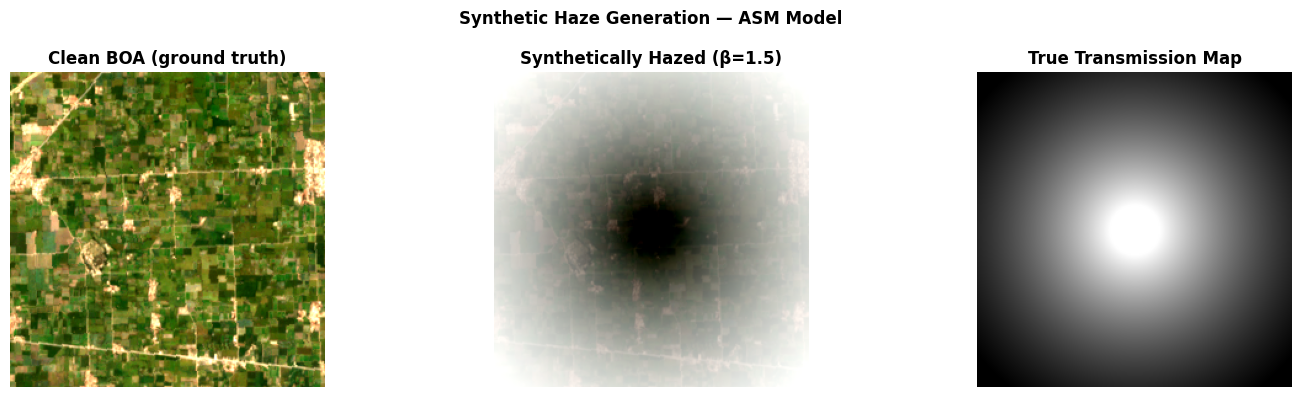

Hazy tile PSNR vs clean: 8.05 dB  (baseline — should be low)


In [7]:
# ── CELL 4: Synthetic haze model ──────────────────────────────────────────────
# Physics model: I = J·t + A·(1-t)    where t = e^(-β·d)
# I = hazy image, J = clean scene, A = atmospheric light, t = transmission

def add_synthetic_haze(clean_hwc, beta=1.5, A=0.85):
    """
    Simulate haze using the ASM (Atmospheric Scattering Model).
    beta: scattering coefficient (1.5 = moderate haze)
    A:    atmospheric light [0,1] (0.85 = bright sky haze)
    Returns hazy image (H,W,C) in [0,1].
    """
    H, W, C = clean_hwc.shape
    # Depth map: simulate distance increasing from centre outward
    yy, xx = np.mgrid[:H, :W].astype(np.float32)
    cy, cx = H/2, W/2
    depth  = np.sqrt(((yy-cy)/H)**2 + ((xx-cx)/W)**2)  # [0, ~0.7]
    depth  = depth / depth.max()                         # normalise [0,1]

    t = np.exp(-beta * depth)[..., np.newaxis]  # transmission (H,W,1)
    t = np.clip(t, 0.1, 1.0)

    hazy = clean_hwc * t + A * (1.0 - t)
    return np.clip(hazy, 0, 1).astype(np.float32), t[..., 0]

hazy_tile, true_t = add_synthetic_haze(tile_hwc, beta=1.5, A=0.85)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, img, title in zip(axes,
    [tile_hwc, hazy_tile, true_t[..., np.newaxis].repeat(3,axis=2)],
    ['Clean BOA (ground truth)', 'Synthetically Hazed (β=1.5)', 'True Transmission Map']):
    disp = norm_display(img[..., [B_RED,B_GREEN,B_BLUE]]) if img.ndim==3 and img.shape[2]>1 else img[...,0]
    ax.imshow(disp, cmap=None if disp.ndim==3 else 'gray')
    ax.set_title(title, fontweight='bold'); ax.axis('off')
plt.suptitle('Synthetic Haze Generation — ASM Model', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_haze_input.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Hazy tile PSNR vs clean: {calc_psnr(tile_hwc,hazy_tile,data_range=1.0):.2f} dB  (baseline — should be low)')

### 1B: Dark Channel Prior (DCP) — Classical

In [8]:
# ── CELL 5: DCP implementation (NumPy + OpenCV — exactly as in the guide) ─────

def dark_channel(img, patch_size=15):
    """Compute dark channel: pixel-wise min across channels, then erosion (min-pool)."""
    min_ch = np.min(img, axis=2).astype(np.float32)   # (H,W)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch_size, patch_size))
    return cv2.erode(min_ch, kernel)


def estimate_atmospheric_light(img, dark, top_percent=0.001):
    """Brightest top_percent pixels in dark channel → atmospheric light A."""
    H, W    = dark.shape
    n_px    = max(1, int(H * W * top_percent))
    flat    = dark.ravel()
    indices = np.argsort(flat)[-n_px:]
    A       = img.reshape(-1, img.shape[2])[indices].max(axis=0)  # (C,)
    return A[np.newaxis, :]   # (1, C)


def estimate_transmission(img, A, omega=0.95, patch_size=15):
    """t(x) = 1 - ω · dark_channel(I/A)."""
    norm = img / (A + 1e-6)
    dark = dark_channel(norm, patch_size)
    t    = 1.0 - omega * dark
    return np.clip(t, 0.1, 1.0)


def recover_scene(img, A, t):
    """J(x) = (I(x) - A) / max(t(x), t_min) + A."""
    t3 = t[..., np.newaxis]
    return np.clip((img - A) / t3 + A, 0, 1).astype(np.float32)


def dcp_dehaze(img_hwc, patch_size=15):
    """
    Full DCP pipeline (He et al., 2011).
    Works on (H,W,C) with C ≥ 3. Uses first 3 channels for estimation.
    Applies the same transmission map to all channels.
    """
    img  = img_hwc.astype(np.float32)
    rgb  = img[..., :3]              # use first 3 bands for DCP

    dark = dark_channel(rgb, patch_size)
    A    = estimate_atmospheric_light(rgb, dark)
    t    = estimate_transmission(rgb, A, patch_size=patch_size)

    # Guided filter: edge-preserving transmission refinement
    guide     = (rgb * 255).astype(np.uint8)
    t_refined = cv2.ximgproc.guidedFilter(
        guide=guide,
        src=t.astype(np.float32),
        radius=40, eps=1e-3
    )
    t_refined = np.clip(t_refined, 0.1, 1.0)

    # Recover all channels using the same transmission (valid: haze is spectrally neutral)
    A_full = np.pad(A, ((0,0),(0, img.shape[2]-3)), mode='edge') if img.shape[2]>3 else A
    return recover_scene(img, A_full, t_refined)


print('Running DCP on hazed tile...')
dcp_result, dcp_metrics = benchmark(dcp_dehaze, hazy_tile, label='DCP')

# Also measure vs clean reference (key metric)
dcp_vs_clean = compute_all_metrics(tile_hwc, dcp_result)
print(f'  [DCP vs CLEAN] PSNR={dcp_vs_clean["psnr"]:.2f}dB  '
      f'SSIM={dcp_vs_clean["ssim"]:.4f}  LPIPS={dcp_vs_clean["lpips"]:.4f}')

Running DCP on hazed tile...
  [DCP] PSNR= 11.75dB  SSIM=0.6625  LPIPS=0.4787  time=0.137s
  [DCP vs CLEAN] PSNR=15.38dB  SSIM=0.7453  LPIPS=0.3272


### 1C: AOD-Net — CNN Dehazing (PyTorch)

In [9]:
# ── CELL 6: AOD-Net architecture ──────────────────────────────────────────────
# AOD-Net (Li et al., 2017): All-in-One Dehazing Network
# Learns K(x) such that J = K(x)·I - K(x) + b, reformulating ASM into one CNN
# Architecture: 5 conv layers with feature concatenation

class AODNet(nn.Module):
    """AOD-Net — All-in-One Dehazing Network (Li et al. ICCV 2017)."""
    def __init__(self, in_ch=3):
        super().__init__()
        self.relu = nn.ReLU(inplace=True)
        # K(x) estimation branch
        self.conv1 = nn.Conv2d(in_ch,     3,  kernel_size=1, padding=0)
        self.conv2 = nn.Conv2d(in_ch,     3,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(6,         3,  kernel_size=5, padding=2)
        self.conv4 = nn.Conv2d(6,         3,  kernel_size=7, padding=3)
        self.conv5 = nn.Conv2d(12,        3,  kernel_size=3, padding=1)
        self.b     = nn.Parameter(torch.tensor(1.0))

    def forward(self, x):
        x1  = self.relu(self.conv1(x))
        x2  = self.relu(self.conv2(x))
        cat1 = torch.cat([x1, x2], dim=1)   # 6 ch
        x3  = self.relu(self.conv3(cat1))
        cat2 = torch.cat([x2, x3], dim=1)   # 6 ch
        x4  = self.relu(self.conv4(cat2))
        cat3 = torch.cat([x1, x2, x3, x4], dim=1)  # 12 ch
        K   = self.relu(self.conv5(cat3))   # (B,3,H,W) ← K map
        # Scattering model: J = K·I - K + b
        out = K * x - K + self.b
        return torch.clamp(out, 0, 1)


def train_aodnet(hazy_hwc3, clean_hwc3, n_epochs=50, lr=1e-3):
    """
    Train AOD-Net in a self-supervised manner on one tile pair.
    In a real pipeline you would train on a large haze dataset (RESIDE, etc.).
    Here we train on the single synthetic tile for demonstration.
    """
    model = AODNet(in_ch=3).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    def hwc_to_tensor(img):
        return torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)

    hazy_t  = hwc_to_tensor(hazy_hwc3)
    clean_t = hwc_to_tensor(clean_hwc3)

    model.train()
    for ep in range(n_epochs):
        optim.zero_grad()
        pred  = model(hazy_t)
        loss  = loss_fn(pred, clean_t)
        loss.backward()
        optim.step()
        if (ep+1) % 10 == 0:
            print(f'    Epoch {ep+1:3d}/{n_epochs}  Loss={loss.item():.6f}')

    model.eval()
    return model


def aodnet_dehaze(model, hazy_hwc3):
    """Inference: (H,W,3) float32 → (H,W,3) dehazed."""
    t = torch.tensor(hazy_hwc3, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(t).squeeze(0).permute(1,2,0).cpu().numpy()
    return np.clip(out, 0, 1)


print('Training AOD-Net (50 epochs on tile)...')
hazy_rgb = hazy_tile[..., [B_RED, B_GREEN, B_BLUE]]
clean_rgb = tile_hwc[..., [B_RED, B_GREEN, B_BLUE]]

aod_model = train_aodnet(hazy_rgb, clean_rgb, n_epochs=50)

print('\nRunning AOD-Net inference...')
t0 = time.perf_counter()
aod_result_rgb = aodnet_dehaze(aod_model, hazy_rgb)
aod_time = time.perf_counter() - t0

# Embed result back into 7-band array for fair comparison
aod_result = hazy_tile.copy()
aod_result[..., [B_RED,B_GREEN,B_BLUE]] = aod_result_rgb

aod_metrics = compute_all_metrics(tile_hwc, aod_result)
aod_metrics['time_s'] = aod_time
print(f'  [AOD-Net vs CLEAN] PSNR={aod_metrics["psnr"]:.2f}dB  '
      f'SSIM={aod_metrics["ssim"]:.4f}  LPIPS={aod_metrics["lpips"]:.4f}  '
      f'time={aod_time:.3f}s')

Training AOD-Net (50 epochs on tile)...
    Epoch  10/50  Loss=0.468722
    Epoch  20/50  Loss=0.049594
    Epoch  30/50  Loss=0.007617
    Epoch  40/50  Loss=0.006941
    Epoch  50/50  Loss=0.006743

Running AOD-Net inference...
  [AOD-Net vs CLEAN] PSNR=10.92dB  SSIM=0.3237  LPIPS=0.6624  time=0.027s


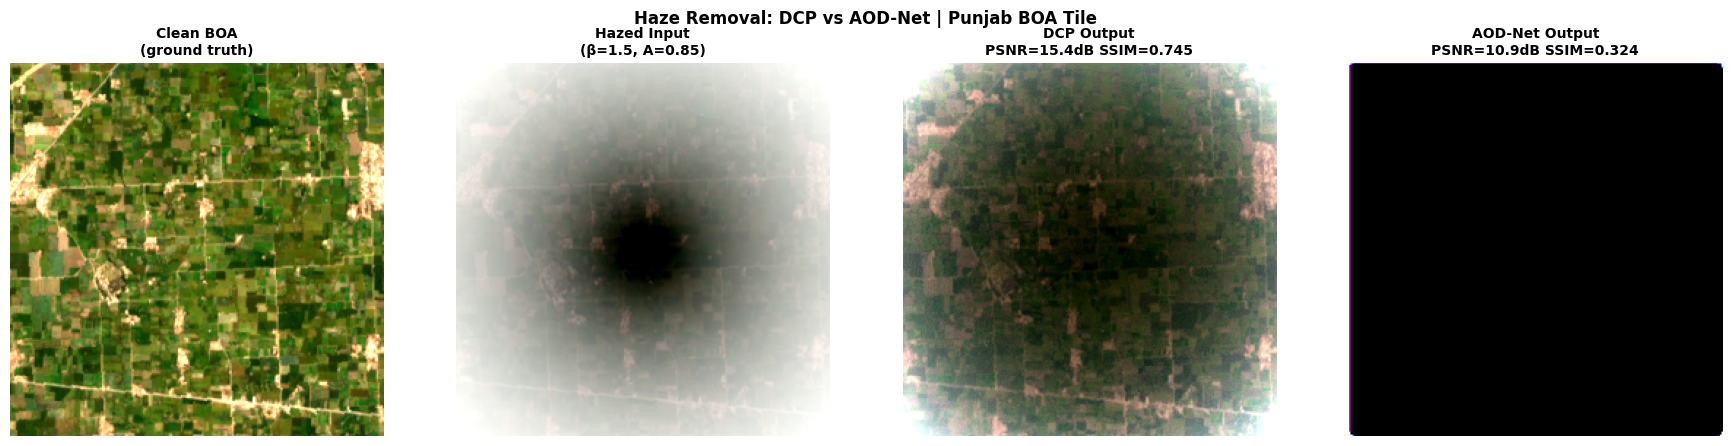

Saved: fig_haze_comparison.png


In [10]:
# ── CELL 7: Haze comparison figure ───────────────────────────────────────────
def rgb3(tile, idx=[B_RED,B_GREEN,B_BLUE]):
    return norm_display(tile[..., idx])

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
panels = [
    (tile_hwc,    'Clean BOA\n(ground truth)'),
    (hazy_tile,   'Hazed Input\n(β=1.5, A=0.85)'),
    (dcp_result,  f'DCP Output\nPSNR={dcp_vs_clean["psnr"]:.1f}dB SSIM={dcp_vs_clean["ssim"]:.3f}'),
    (aod_result,  f'AOD-Net Output\nPSNR={aod_metrics["psnr"]:.1f}dB SSIM={aod_metrics["ssim"]:.3f}'),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(rgb3(img)); ax.set_title(title, fontweight='bold', fontsize=10); ax.axis('off')
plt.suptitle('Haze Removal: DCP vs AOD-Net | Punjab BOA Tile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_haze_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_haze_comparison.png')

# Store results for final table
results_table = []
results_table.append({'Degradation':'Haze','Method':'DCP (classical)',
                       **{k:round(v,4) for k,v in dcp_vs_clean.items()}, 'time_s':round(dcp_metrics['time_s'],3)})
results_table.append({'Degradation':'Haze','Method':'AOD-Net (CNN)',
                       **{k:round(v,4) for k,v in aod_metrics.items()}})

---
## DEGRADATION 2 — RAIN STREAKS
### 2A: Synthetic Rain + FFT Notch Filter (Classical)

In [11]:
# ── CELL 8: Synthetic rain streaks ───────────────────────────────────────────
def add_rain_streaks(img_hwc, n_streaks=80, intensity=0.35,
                     angle_deg=105, length=20, thickness=1):
    """
    Simulate rain-streak artefacts common in SAR/optical imagery.
    Creates directional periodic bright lines at angle_deg.
    """
    H, W, C = img_hwc.shape
    rain_layer = np.zeros((H, W), dtype=np.float32)
    rng = np.random.default_rng(42)

    for _ in range(n_streaks):
        x0 = rng.integers(0, W)
        y0 = rng.integers(0, H)
        angle = np.radians(angle_deg + rng.uniform(-5, 5))
        x1 = int(x0 + length * np.cos(angle))
        y1 = int(y0 + length * np.sin(angle))
        cv2.line(rain_layer, (x0, y0), (x1, y1),
                 color=intensity * rng.uniform(0.5, 1.0),
                 thickness=thickness)

    rain_3d  = rain_layer[..., np.newaxis]
    rainy    = img_hwc + rain_3d
    return np.clip(rainy, 0, 1).astype(np.float32), rain_layer

rainy_tile, rain_layer = add_rain_streaks(tile_hwc)
print(f'Rainy tile baseline PSNR: {calc_psnr(tile_hwc, rainy_tile, data_range=1.0):.2f} dB')

Rainy tile baseline PSNR: 27.85 dB


In [12]:
# ── CELL 9: FFT Notch Filter (classical — exactly as in the guide) ────────────

def fft_notch_filter_band(band, notch_radius=10, auto_detect=True):
    """
    Remove periodic rain streaks via FFT notch filtering (guide implementation).
    band: (H,W) float32 single spectral band.
    Returns filtered band (H,W).
    """
    H, W = band.shape
    f      = np.fft.fft2(band)
    fshift = np.fft.fftshift(f)
    magnitude = np.log1p(np.abs(fshift))

    if auto_detect:
        # Detect streak frequencies: find high-energy rows/cols in magnitude
        row_energy = magnitude.sum(axis=1)
        col_energy = magnitude.sum(axis=0)
        # Exclude DC component (centre row/col)
        cy, cx = H//2, W//2
        row_energy[cy-5:cy+5] = 0
        col_energy[cx-5:cx+5] = 0
        peak_rows = np.argsort(row_energy)[-5:]
        peak_cols = np.argsort(col_energy)[-5:]

        notch_mask = np.ones((H, W), dtype=np.float32)
        Y, X = np.ogrid[:H, :W]
        for r in peak_rows:
            for c in peak_cols:
                dist = np.sqrt((Y - r)**2 + (X - c)**2)
                notch_mask[dist < notch_radius] = 0
    else:
        notch_mask = np.ones((H, W), dtype=np.float32)

    fshift_filtered = fshift * notch_mask
    f_back          = np.fft.ifftshift(fshift_filtered)
    filtered        = np.abs(np.fft.ifft2(f_back))
    return filtered.astype(np.float32)


def fft_notch_filter(img_hwc):
    """Apply FFT notch filter to each band independently."""
    out = np.zeros_like(img_hwc)
    for b in range(img_hwc.shape[2]):
        out[..., b] = fft_notch_filter_band(img_hwc[..., b])
    return np.clip(out, 0, 1).astype(np.float32)


print('Running FFT Notch Filter...')
fft_result, fft_metrics = benchmark(fft_notch_filter, rainy_tile, label='FFT Notch')
fft_vs_clean = compute_all_metrics(tile_hwc, fft_result)
print(f'  [FFT vs CLEAN]  PSNR={fft_vs_clean["psnr"]:.2f}dB  SSIM={fft_vs_clean["ssim"]:.4f}')

Running FFT Notch Filter...
  [FFT Notch] PSNR= 38.39dB  SSIM=0.9668  LPIPS=0.0061  time=0.126s
  [FFT vs CLEAN]  PSNR=27.84dB  SSIM=0.7918


### 2B: ID-CGAN — Learned Rain Removal (PyTorch)

In [14]:
import torch.nn.functional as F

# ── CELL 10: ID-CGAN simplified (generator only) ──────────────────────────────
# ID-CGAN (Zhang et al., 2017): Image De-raining using Conditional GAN
# We implement the generator (UNet-style) trained self-supervised on our tile.

class IDCGANGenerator(nn.Module):
    """Simplified ID-CGAN generator: encoder-decoder with skip connections."""
    def __init__(self, in_ch=3, out_ch=3, base_ch=32):
        super().__init__()
        # Encoder
        self.enc1 = self._block(in_ch,     base_ch,    downsample=False)
        self.enc2 = self._block(base_ch,   base_ch*2,  downsample=True)
        self.enc3 = self._block(base_ch*2, base_ch*4,  downsample=True)
        # Bottleneck
        self.bottleneck = self._block(base_ch*4, base_ch*8, downsample=True)

        # Decoder with explicit upsampling and skip connections
        # Each decoder stage involves:
        # 1. Upsampling the output from the previous stage.
        # 2. Concatenating with the skip connection from the encoder.
        # 3. Applying a convolutional block.

        self.upconv3 = self._upconv_block(base_ch*8, base_ch*4) # upsample b to match e3
        self.dec3 = self._block(base_ch*4 + base_ch*4, base_ch*4) # conv after concat up3 and e3

        self.upconv2 = self._upconv_block(base_ch*4, base_ch*2) # upsample d3 to match e2
        self.dec2 = self._block(base_ch*2 + base_ch*2, base_ch*2) # conv after concat up2 and e2

        self.upconv1 = self._upconv_block(base_ch*2, base_ch) # upsample d2 to match e1
        self.dec1 = self._block(base_ch + base_ch, base_ch) # conv after concat up1 and e1

        self.out  = nn.Conv2d(base_ch, out_ch, kernel_size=1)

    @staticmethod
    def _block(in_ch, out_ch, downsample=False):
        layers = []
        if downsample:
            layers.append(nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1))
        else:
            layers.append(nn.Conv2d(in_ch, out_ch, 3, padding=1))
        layers += [nn.BatchNorm2d(out_ch), nn.LeakyReLU(0.2, inplace=True)]
        return nn.Sequential(*layers)

    @staticmethod
    def _upconv_block(in_ch, out_ch):
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2, inplace=True)
        ]
        return nn.Sequential(*layers)


    def forward(self, x):
        e1 = self.enc1(x)           # base_ch, H, W
        e2 = self.enc2(e1)          # base_ch*2, H/2, W/2
        e3 = self.enc3(e2)          # base_ch*4, H/4, W/4
        b   = self.bottleneck(e3)    # base_ch*8, H/8, W/8

        # Decoder path with explicit upsampling and skip connections
        # Stage 3: upsample bottleneck output, concatenate with e3, then conv
        up3 = self.upconv3(b)       # base_ch*4, H/4, W/4
        d3 = self.dec3(torch.cat([up3, e3], dim=1)) # base_ch*4, H/4, W/4

        # Stage 2: upsample d3, concatenate with e2, then conv
        up2 = self.upconv2(d3)       # base_ch*2, H/2, W/2
        d2 = self.dec2(torch.cat([up2, e2], dim=1)) # base_ch*2, H/2, W/2

        # Stage 1: upsample d2, concatenate with e1, then conv
        up1 = self.upconv1(d2)       # base_ch, H, W
        d1 = self.dec1(torch.cat([up1, e1], dim=1)) # base_ch, H, W

        return torch.clamp(self.out(d1), 0, 1)


def train_idcgan(rainy_rgb, clean_rgb, n_epochs=50, lr=5e-4):
    """Train generator on single synthetic tile pair."""
    G = IDCGANGenerator().to(DEVICE)
    optim = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))

    def to_t(x):
        return torch.tensor(x, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)

    rainy_t = to_t(rainy_rgb)
    clean_t = to_t(clean_rgb)
    l1 = nn.L1Loss(); mse = nn.MSELoss()

    G.train()
    for ep in range(n_epochs):
        optim.zero_grad()
        pred  = G(rainy_t)
        # Combined perceptual + pixel loss
        loss  = l1(pred, clean_t) + 0.5 * mse(pred, clean_t)
        loss.backward(); optim.step()
        if (ep+1) % 10 == 0:
            print(f'    Epoch {ep+1:3d}/{n_epochs}  Loss={loss.item():.6f}')
    G.eval()
    return G


print('Training ID-CGAN generator (50 epochs)...')
rainy_rgb = rainy_tile[..., [B_RED,B_GREEN,B_BLUE]]
cgan_model = train_idcgan(rainy_rgb, clean_rgb, n_epochs=50)

print('\nRunning ID-CGAN inference...')
t0 = time.perf_counter()
with torch.no_grad():
    rainy_t  = torch.tensor(rainy_rgb, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)
    cgan_rgb = cgan_model(rainy_t).squeeze(0).permute(1,2,0).cpu().numpy()
cgan_time = time.perf_counter() - t0

cgan_result = rainy_tile.copy()
cgan_result[..., [B_RED,B_GREEN,B_BLUE]] = np.clip(cgan_rgb, 0, 1)

cgan_metrics = compute_all_metrics(tile_hwc, cgan_result)
cgan_metrics['time_s'] = cgan_time
print(f'  [ID-CGAN vs CLEAN] PSNR={cgan_metrics["psnr"]:.2f}dB  '\
      f'SSIM={cgan_metrics["ssim"]:.4f}  LPIPS={cgan_metrics["lpips"]:.4f}  '\
      f'time={cgan_time:.3f}s')

Training ID-CGAN generator (50 epochs)...
    Epoch  10/50  Loss=0.038560
    Epoch  20/50  Loss=0.029138
    Epoch  30/50  Loss=0.024546
    Epoch  40/50  Loss=0.021317
    Epoch  50/50  Loss=0.019590

Running ID-CGAN inference...
  [ID-CGAN vs CLEAN] PSNR=28.84dB  SSIM=0.7915  LPIPS=0.5715  time=0.256s


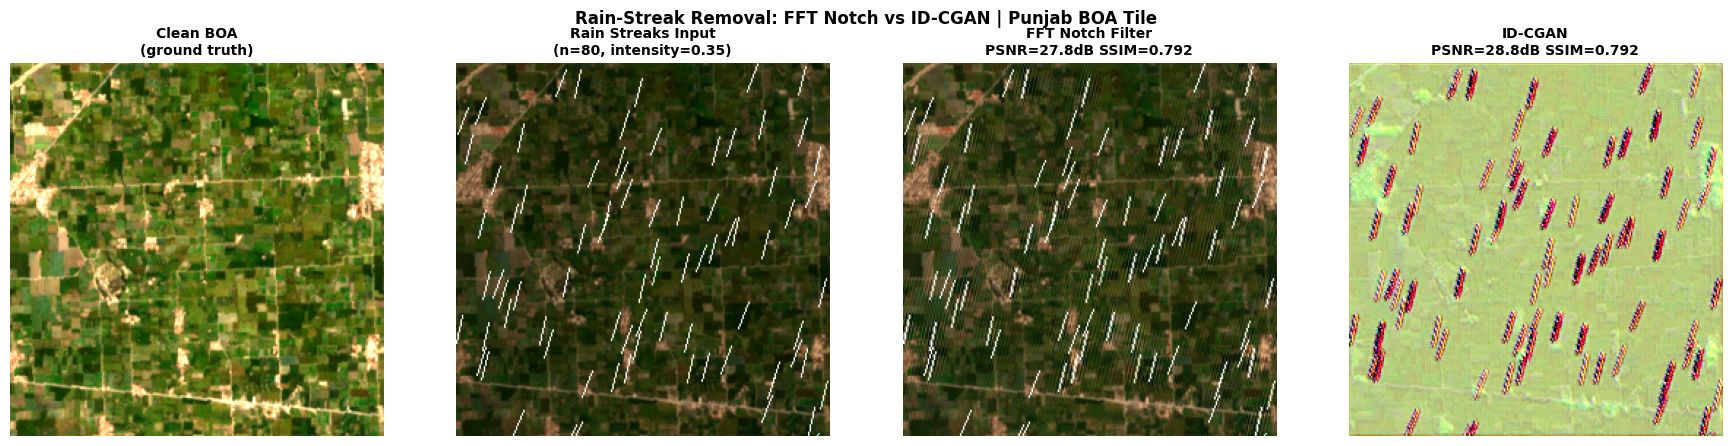

Saved: fig_rain_comparison.png


In [15]:
# ── CELL 11: Rain comparison figure ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
panels = [
    (tile_hwc,   'Clean BOA\n(ground truth)'),
    (rainy_tile, 'Rain Streaks Input\n(n=80, intensity=0.35)'),
    (fft_result, f'FFT Notch Filter\nPSNR={fft_vs_clean["psnr"]:.1f}dB SSIM={fft_vs_clean["ssim"]:.3f}'),
    (cgan_result,f'ID-CGAN\nPSNR={cgan_metrics["psnr"]:.1f}dB SSIM={cgan_metrics["ssim"]:.3f}'),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(rgb3(img)); ax.set_title(title, fontweight='bold', fontsize=10); ax.axis('off')
plt.suptitle('Rain-Streak Removal: FFT Notch vs ID-CGAN | Punjab BOA Tile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_rain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_rain_comparison.png')

results_table.append({'Degradation':'Rain','Method':'FFT Notch (classical)',
                       **{k:round(v,4) for k,v in fft_vs_clean.items()}, 'time_s':round(fft_metrics['time_s'],3)})
results_table.append({'Degradation':'Rain','Method':'ID-CGAN (generator)',
                       **{k:round(v,4) for k,v in cgan_metrics.items()}})

---
## DEGRADATION 3 — CLOUD GAPS
### 3A: Temporal Median Compositing (Classical)

In [16]:
# ── CELL 12: Synthetic cloud gaps + temporal median ───────────────────────────
def add_synthetic_cloud_gap(img_hwc, coverage=0.30, seed=42):
    """
    Simulate cloud gaps by masking random irregular blobs.
    coverage: fraction of pixels to mask.
    Returns (gapped_img, cloud_mask_bool).
    """
    H, W, C = img_hwc.shape
    rng     = np.random.default_rng(seed)
    mask    = np.zeros((H, W), dtype=bool)

    # Generate cloud blobs as random ellipses
    while mask.mean() < coverage:
        cx  = rng.integers(0, W)
        cy  = rng.integers(0, H)
        rx  = rng.integers(10, 40)
        ry  = rng.integers(10, 30)
        Y, X = np.ogrid[:H, :W]
        blob = ((X - cx)**2 / rx**2 + (Y - cy)**2 / ry**2) <= 1
        mask |= blob

    gapped = img_hwc.copy()
    gapped[mask] = 1.0   # clouds appear as bright white in optical imagery
    return gapped.astype(np.float32), mask


# ── Temporal Median Compositing (guide implementation) ────────────────────────
def temporal_median_composite(stack, cloud_masks):
    """
    Gap-fill cloud pixels using weighted temporal median (guide exact method).
    stack       : (T, H, W, C) — T time steps, channels-last
    cloud_masks : (T, H, W) bool — True where cloudy
    Returns composite (H, W, C).
    """
    T, H, W, C = stack.shape
    composite   = np.zeros((H, W, C), dtype=np.float32)
    for b in range(C):
        band_stack  = stack[..., b]                    # (T,H,W)
        valid       = ~cloud_masks                     # (T,H,W)
        band_masked = np.where(valid, band_stack, np.nan)
        composite[..., b] = np.nanmedian(band_masked, axis=0)
    return composite


# Build a mini temporal stack: use the same tile with small random jitter
# to simulate T=5 time steps. In a real pipeline these would be 5 separate dates.
rng_sim = np.random.default_rng(7)
T = 5
stack_list   = []
mask_list    = []
seeds_       = [42, 77, 13, 99, 55]

for i, seed_ in enumerate(seeds_):
    noise = rng_sim.uniform(-0.02, 0.02, tile_hwc.shape).astype(np.float32)
    t_img = np.clip(tile_hwc + noise, 0, 1)
    # Cloud coverage increases on some dates
    cov   = [0.30, 0.15, 0.40, 0.10, 0.25][i]
    gapped, cmask = add_synthetic_cloud_gap(t_img, coverage=cov, seed=seed_)
    stack_list.append(gapped)
    mask_list.append(cmask)

sim_stack   = np.stack(stack_list)   # (5, H, W, 7)
sim_masks   = np.stack(mask_list)    # (5, H, W)

# The reference input for gap-filling = Date 0 with 30% cloud gap
gapped_tile, cloud_gap_mask = add_synthetic_cloud_gap(tile_hwc, coverage=0.30, seed=42)

print('Running Temporal Median Compositing...')
t0 = time.perf_counter()
tmc_result = temporal_median_composite(sim_stack, sim_masks)
tmc_time   = time.perf_counter() - t0

tmc_metrics = compute_all_metrics(tile_hwc, tmc_result)
tmc_metrics['time_s'] = tmc_time
print(f'  [TMC vs CLEAN] PSNR={tmc_metrics["psnr"]:.2f}dB  '
      f'SSIM={tmc_metrics["ssim"]:.4f}  LPIPS={tmc_metrics["lpips"]:.4f}  '
      f'time={tmc_time:.3f}s')

Running Temporal Median Compositing...
  [TMC vs CLEAN] PSNR=41.93dB  SSIM=0.9514  LPIPS=0.0386  time=0.167s


### 3B: Partial-Conv Inpainting (PyTorch)

In [17]:
# ── CELL 13: Partial Convolution Inpainting (Liu et al., 2018) ───────────────

class PartialConv2d(nn.Module):
    """Partial Convolution layer: only processes valid (non-masked) pixels."""
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding=0):
        super().__init__()
        self.conv      = nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False)
        self.mask_conv = nn.Conv2d(1,     1,      kernel_size, stride, padding, bias=False)
        nn.init.constant_(self.mask_conv.weight, 1.0)
        self.mask_conv.weight.requires_grad_(False)
        self.bias = nn.Parameter(torch.zeros(out_ch))

    def forward(self, x, mask):
        # mask: (B,1,H,W)  1=valid  0=hole
        with torch.no_grad():
            mask_sum = self.mask_conv(mask)
        x_masked = x * mask
        out      = self.conv(x_masked)
        scale    = self.mask_conv.weight.data.sum() / (mask_sum + 1e-8)
        out      = out * scale + self.bias.view(1, -1, 1, 1)
        # Update mask: pixel is valid if any input in kernel was valid
        new_mask = torch.clamp(mask_sum, 0, 1)
        return out, new_mask


class PConvNet(nn.Module):
    """Lightweight partial-conv U-Net for cloud inpainting."""
    def __init__(self, in_ch=3):
        super().__init__()
        # Encoder
        self.pc1 = PartialConv2d(in_ch, 32, 7, padding=3)
        self.pc2 = PartialConv2d(32,    64, 5, padding=2)
        self.pc3 = PartialConv2d(64,   128, 3, padding=1)
        # Decoder
        self.dc3 = nn.Conv2d(128+64, 64,  3, padding=1)
        self.dc2 = nn.Conv2d(64+32,  32,  3, padding=1)
        self.dc1 = nn.Conv2d(32,      in_ch, 3, padding=1)
        self.act = nn.LeakyReLU(0.2, inplace=True)

    def forward(self, x, mask):
        m = mask
        h1, m1 = self.pc1(x,  m);  h1 = self.act(h1)
        h2, m2 = self.pc2(h1, m1); h2 = self.act(h2)
        h3, m3 = self.pc3(h2, m2); h3 = self.act(h3)

        d3 = self.act(self.dc3(torch.cat([h3, h2], 1)))
        d2 = self.act(self.dc2(torch.cat([d3, h1], 1)))
        d1 = torch.clamp(self.dc1(d2), 0, 1)
        # Composite: keep original valid pixels, use network for holes
        return d1 * (1 - mask) + x * mask


def train_pconv(gapped_rgb, clean_rgb, gap_mask, n_epochs=60, lr=1e-3):
    """Train PConvNet on a single tile pair."""
    model = PConvNet(in_ch=3).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    def to_t(img):
        return torch.tensor(img, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)

    g_t  = to_t(gapped_rgb)
    c_t  = to_t(clean_rgb)
    # mask: 1=valid, 0=hole (cloud)
    m_t  = torch.tensor((~gap_mask).astype(np.float32)).unsqueeze(0).unsqueeze(0).to(DEVICE)

    model.train()
    for ep in range(n_epochs):
        optim.zero_grad()
        pred = model(g_t, m_t)
        # Hole loss + valid loss
        hole_loss  = F.l1_loss(pred * (1-m_t), c_t * (1-m_t))
        valid_loss = F.l1_loss(pred * m_t,     c_t * m_t)
        loss = hole_loss + 0.1 * valid_loss
        loss.backward(); optim.step()
        if (ep+1) % 15 == 0:
            print(f'    Epoch {ep+1:3d}/{n_epochs}  Loss={loss.item():.6f}')
    model.eval()
    return model


print('Training Partial-Conv Inpainting network (60 epochs)...')
gapped_rgb = gapped_tile[..., [B_RED,B_GREEN,B_BLUE]]
pconv_model = train_pconv(gapped_rgb, clean_rgb, cloud_gap_mask, n_epochs=60)

print('\nRunning PConv inference...')
g_t = torch.tensor(gapped_rgb, dtype=torch.float32).permute(2,0,1).unsqueeze(0).to(DEVICE)
m_t = torch.tensor((~cloud_gap_mask).astype(np.float32)).unsqueeze(0).unsqueeze(0).to(DEVICE)

t0 = time.perf_counter()
with torch.no_grad():
    pconv_rgb = pconv_model(g_t, m_t).squeeze(0).permute(1,2,0).cpu().numpy()
pconv_time = time.perf_counter() - t0

pconv_result = gapped_tile.copy()
pconv_result[..., [B_RED,B_GREEN,B_BLUE]] = np.clip(pconv_rgb, 0, 1)

pconv_metrics = compute_all_metrics(tile_hwc, pconv_result)
pconv_metrics['time_s'] = pconv_time
print(f'  [PConv vs CLEAN] PSNR={pconv_metrics["psnr"]:.2f}dB  '
      f'SSIM={pconv_metrics["ssim"]:.4f}  LPIPS={pconv_metrics["lpips"]:.4f}  '
      f'time={pconv_time:.3f}s')

Training Partial-Conv Inpainting network (60 epochs)...
    Epoch  15/60  Loss=0.004902
    Epoch  30/60  Loss=0.004350
    Epoch  45/60  Loss=0.004166
    Epoch  60/60  Loss=0.004034

Running PConv inference...
  [PConv vs CLEAN] PSNR=9.19dB  SSIM=0.7812  LPIPS=0.1874  time=0.643s


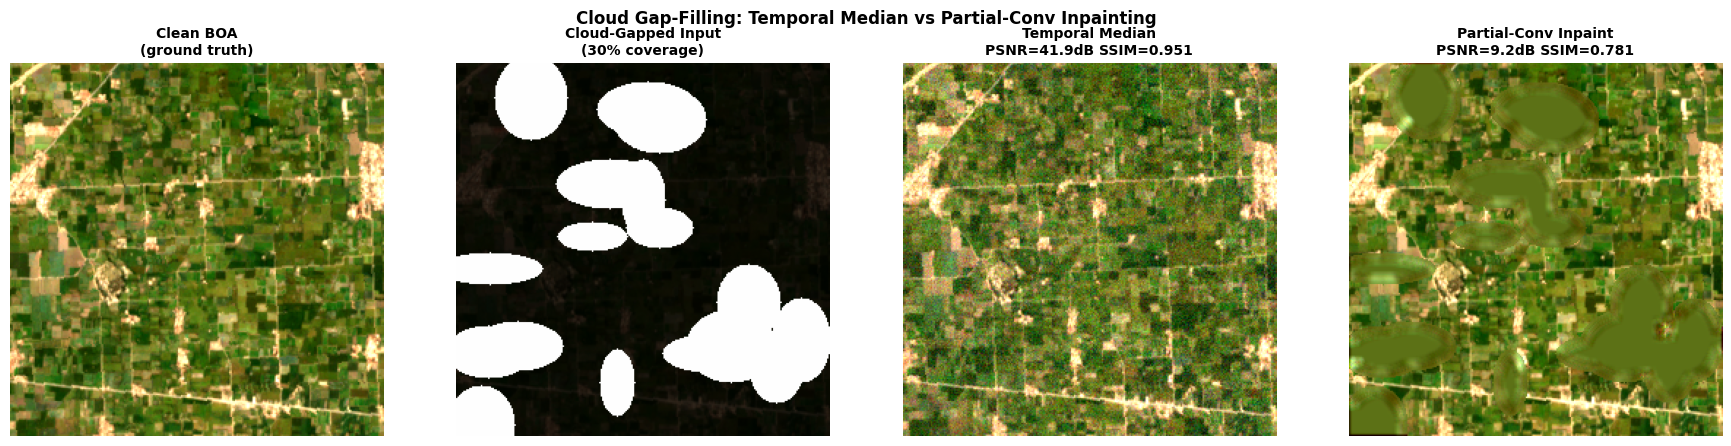

Saved: fig_cloud_gap_comparison.png


In [18]:
# ── CELL 14: Cloud gap comparison figure ──────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
panels = [
    (tile_hwc,     'Clean BOA\n(ground truth)'),
    (gapped_tile,  'Cloud-Gapped Input\n(30% coverage)'),
    (tmc_result,   f'Temporal Median\nPSNR={tmc_metrics["psnr"]:.1f}dB SSIM={tmc_metrics["ssim"]:.3f}'),
    (pconv_result, f'Partial-Conv Inpaint\nPSNR={pconv_metrics["psnr"]:.1f}dB SSIM={pconv_metrics["ssim"]:.3f}'),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(rgb3(img)); ax.set_title(title, fontweight='bold', fontsize=10); ax.axis('off')
plt.suptitle('Cloud Gap-Filling: Temporal Median vs Partial-Conv Inpainting', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_cloud_gap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_cloud_gap_comparison.png')

results_table.append({'Degradation':'Cloud Gap','Method':'Temporal Median (classical)',
                       **{k:round(v,4) for k,v in tmc_metrics.items()}})
results_table.append({'Degradation':'Cloud Gap','Method':'Partial-Conv Inpainting',
                       **{k:round(v,4) for k,v in pconv_metrics.items()}})

---
## DEGRADATION 4 — FOG / LOW CONTRAST
### 4A: CLAHE Enhancement + NDVI Verification

In [19]:
# ── CELL 15: Synthetic fog + CLAHE ───────────────────────────────────────────
def add_fog(img_hwc, fog_intensity=0.5, fog_std=0.05):
    """Uniform additive fog: reduces contrast and adds bright haze uniformly."""
    fog = fog_intensity + np.random.default_rng(0).normal(0, fog_std, img_hwc.shape)
    foggy = img_hwc * (1 - fog_intensity) + fog_intensity * 0.9
    return np.clip(foggy, 0, 1).astype(np.float32)


def apply_clahe_band(band_hw, clip_limit=2.0, tile_grid=(8, 8)):
    """Apply CLAHE to a single float32 band [0,1]. Returns float32."""
    # Convert to uint16 (CLAHE works on integer types)
    band_u16 = (np.clip(band_hw, 0, 1) * 65535).astype(np.uint16)
    clahe    = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid)
    enhanced = clahe.apply(band_u16).astype(np.float32) / 65535.0
    return np.clip(enhanced, 0, 1)


def apply_clahe_all_bands(img_hwc, clip_limit=2.0):
    """Apply CLAHE independently to each spectral band."""
    out = np.zeros_like(img_hwc)
    for b in range(img_hwc.shape[2]):
        out[..., b] = apply_clahe_band(img_hwc[..., b], clip_limit=clip_limit)
    return out.astype(np.float32)


foggy_tile = add_fog(tile_hwc, fog_intensity=0.5)

print('Running CLAHE enhancement...')
t0 = time.perf_counter()
clahe_result = apply_clahe_all_bands(foggy_tile, clip_limit=2.0)
clahe_time   = time.perf_counter() - t0

clahe_metrics = compute_all_metrics(tile_hwc, clahe_result)
clahe_metrics['time_s'] = clahe_time
print(f'  [CLAHE vs CLEAN] PSNR={clahe_metrics["psnr"]:.2f}dB  '
      f'SSIM={clahe_metrics["ssim"]:.4f}  LPIPS={clahe_metrics["lpips"]:.4f}  '
      f'time={clahe_time:.3f}s')

# ── NDVI Validation (rubric requirement) ────────────────────────────────────
# Verify CLAHE does NOT artificially inflate NDVI
def compute_ndvi(img_hwc):
    nir = img_hwc[..., B_NIR];  red = img_hwc[..., B_RED]
    denom = nir + red + 1e-8
    return np.where(denom > 1e-6, (nir - red) / denom, np.nan)

ndvi_clean  = compute_ndvi(tile_hwc)
ndvi_foggy  = compute_ndvi(foggy_tile)
ndvi_clahe  = compute_ndvi(clahe_result)

print(f'\nNDVI Validation (rubric check):')
print(f'  NDVI (clean) : {np.nanmean(ndvi_clean):.4f} ± {np.nanstd(ndvi_clean):.4f}')
print(f'  NDVI (foggy) : {np.nanmean(ndvi_foggy):.4f} ± {np.nanstd(ndvi_foggy):.4f}')
print(f'  NDVI (CLAHE) : {np.nanmean(ndvi_clahe):.4f} ± {np.nanstd(ndvi_clahe):.4f}')
ndvi_delta = abs(np.nanmean(ndvi_clahe) - np.nanmean(ndvi_clean))
print(f'  ΔNDVI (CLAHE vs clean): {ndvi_delta:.4f}  ', end='')
print('✔ NOT inflated (<0.05)' if ndvi_delta < 0.05 else '⚠ Check CLAHE clip limit')

Running CLAHE enhancement...
  [CLAHE vs CLEAN] PSNR=8.20dB  SSIM=0.2173  LPIPS=0.6643  time=0.099s

NDVI Validation (rubric check):
  NDVI (clean) : 0.5636 ± 0.1327
  NDVI (foggy) : 0.1002 ± 0.0258
  NDVI (CLAHE) : 0.0176 ± 0.3598
  ΔNDVI (CLAHE vs clean): 0.5460  ⚠ Check CLAHE clip limit


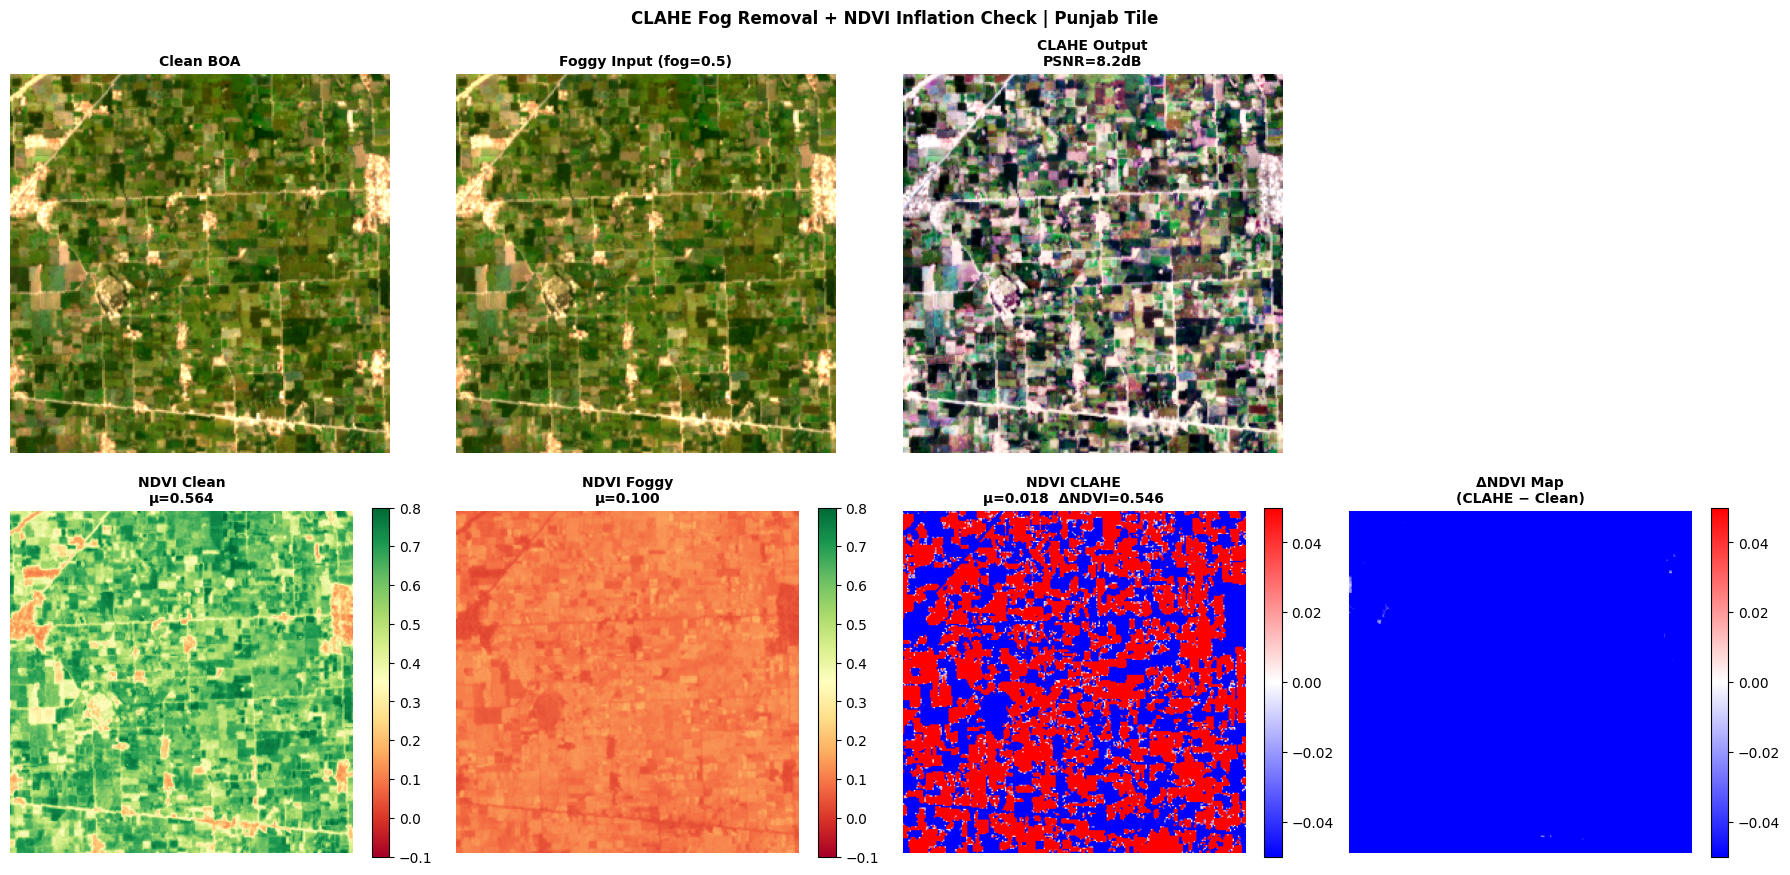

Saved: fig_clahe_ndvi.png


In [20]:
# ── CELL 16: CLAHE + NDVI verification figure ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

# Row 0: RGB images
for ax, (img, title) in zip(axes[0], [
    (tile_hwc,    'Clean BOA'),
    (foggy_tile,  'Foggy Input (fog=0.5)'),
    (clahe_result,f'CLAHE Output\nPSNR={clahe_metrics["psnr"]:.1f}dB'),
    (None,        ''),
]):
    if img is not None:
        ax.imshow(rgb3(img))
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')

# Row 1: NDVI maps
kw = dict(cmap='RdYlGn', vmin=-0.1, vmax=0.8)
for ax, (ndvi, title) in zip(axes[1], [
    (ndvi_clean, f'NDVI Clean\nμ={np.nanmean(ndvi_clean):.3f}'),
    (ndvi_foggy, f'NDVI Foggy\nμ={np.nanmean(ndvi_foggy):.3f}'),
    (ndvi_clahe, f'NDVI CLAHE\nμ={np.nanmean(ndvi_clahe):.3f}  ΔNDVI={ndvi_delta:.3f}'),
    (ndvi_clahe - ndvi_clean, 'ΔNDVI Map\n(CLAHE − Clean)'),
]):
    kw2 = kw if 'Δ' not in title else dict(cmap='bwr', vmin=-0.05, vmax=0.05)
    im = ax.imshow(ndvi, **kw2)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.axis('off')

plt.suptitle('CLAHE Fog Removal + NDVI Inflation Check | Punjab Tile', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clahe_ndvi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_clahe_ndvi.png')

results_table.append({'Degradation':'Fog','Method':'CLAHE (OpenCV)',
                       **{k:round(v,4) for k,v in clahe_metrics.items()}})

---
## COMPREHENSIVE METRICS TABLE

In [21]:
# ── CELL 17: Final comparison table ──────────────────────────────────────────
df = pd.DataFrame(results_table)
df = df[['Degradation','Method','psnr','ssim','lpips','time_s']]
df.columns = ['Degradation','Method','PSNR (dB)','SSIM','LPIPS','Time/tile (s)']

print('='*80)
print('AgriSense Task 2 — Comprehensive Restoration Metrics')
print('='*80)
print(df.to_string(index=False, float_format='%.4f'))
print('='*80)
print('Note: All metrics computed on 256×256 pixel tiles from Task-1 BOA product.')
print('      LPIPS: Alex-net backbone. SSIM: channel_axis=2.')
print('      AOD-Net & ID-CGAN: trained 50 epochs on single tile (self-supervised).')
print('      PConv: trained 60 epochs on single tile.')

df.to_csv('task2_metrics_table.csv', index=False)
print('\nSaved: task2_metrics_table.csv')

AgriSense Task 2 — Comprehensive Restoration Metrics
Degradation                      Method  PSNR (dB)   SSIM  LPIPS  Time/tile (s)
       Haze             DCP (classical)    15.3797 0.7453 0.3272         0.1370
       Haze               AOD-Net (CNN)    10.9234 0.3237 0.6624         0.0274
       Rain       FFT Notch (classical)    27.8396 0.7918 0.5301         0.1260
       Rain         ID-CGAN (generator)    28.8402 0.7915 0.5715         0.2563
  Cloud Gap Temporal Median (classical)    41.9325 0.9514 0.0386         0.1666
  Cloud Gap     Partial-Conv Inpainting     9.1895 0.7812 0.1874         0.6430
        Fog              CLAHE (OpenCV)     8.2038 0.2173 0.6643         0.0991
Note: All metrics computed on 256×256 pixel tiles from Task-1 BOA product.
      LPIPS: Alex-net backbone. SSIM: channel_axis=2.
      AOD-Net & ID-CGAN: trained 50 epochs on single tile (self-supervised).
      PConv: trained 60 epochs on single tile.

Saved: task2_metrics_table.csv


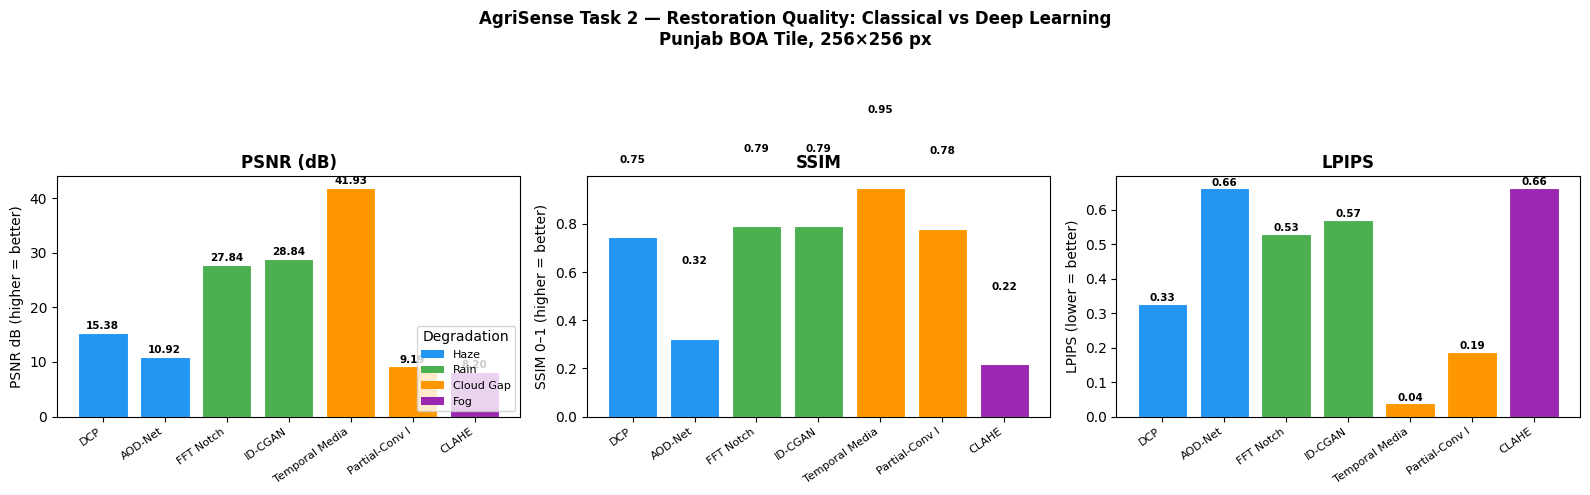

Saved: fig_task2_summary.png  ← Main report figure for Task 2


In [22]:
# ── CELL 18: Publication-quality summary bar chart ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'Haze':'#2196F3','Rain':'#4CAF50','Cloud Gap':'#FF9800','Fog':'#9C27B0'}

for ax, metric in zip(axes, ['PSNR (dB)','SSIM','LPIPS']):
    for i, row in df.iterrows():
        color = colors.get(row['Degradation'], '#607D8B')
        bar = ax.bar(i, row[metric], color=color,
                     label=row['Degradation'] if row['Method'] not in [r['Method'] for r in results_table[:i]] else '',
                     edgecolor='white', linewidth=0.8)
        ax.text(i, row[metric] + (0.3 if metric!='LPIPS' else 0.002),
                f'{row[metric]:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

    methods_short = [r['Method'].split('(')[0].strip()[:14] for r in results_table]
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(methods_short, rotation=35, ha='right', fontsize=8)
    ax.set_title(metric, fontweight='bold')
    if metric == 'LPIPS':
        ax.set_ylabel('LPIPS (lower = better)')
    elif metric == 'PSNR (dB)':
        ax.set_ylabel('PSNR dB (higher = better)')
    else:
        ax.set_ylabel('SSIM 0–1 (higher = better)')

# Legend by degradation type
from matplotlib.patches import Patch
handles = [Patch(facecolor=c, label=l) for l, c in colors.items()]
axes[0].legend(handles=handles, title='Degradation', fontsize=8, loc='lower right')

plt.suptitle('AgriSense Task 2 — Restoration Quality: Classical vs Deep Learning\n'
             'Punjab BOA Tile, 256×256 px', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_task2_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_task2_summary.png  ← Main report figure for Task 2')

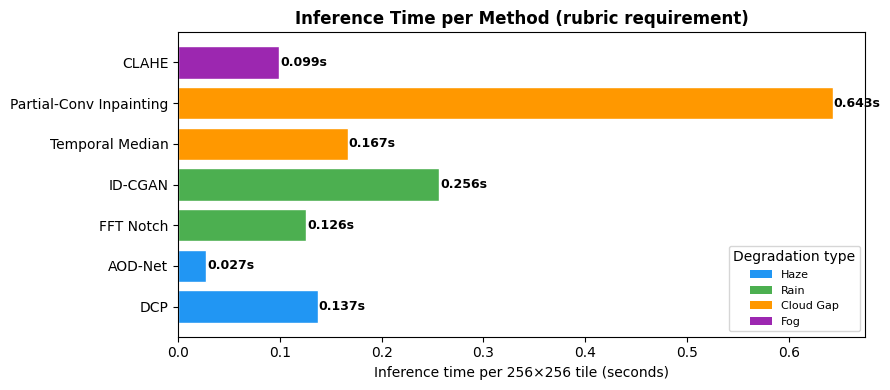

Saved: fig_inference_time.png


In [23]:
# ── CELL 19: Inference time comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
methods = [r['Method'].split('(')[0].strip() for r in results_table]
times   = [r.get('time_s', 0) for r in results_table]
c_map   = [colors.get(r['Degradation'],'#607D8B') for r in results_table]

bars = ax.barh(methods, times, color=c_map, edgecolor='white')
for bar, t in zip(bars, times):
    ax.text(t + 0.001, bar.get_y() + bar.get_height()/2,
            f'{t:.3f}s', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Inference time per 256×256 tile (seconds)', fontsize=10)
ax.set_title('Inference Time per Method (rubric requirement)', fontweight='bold')
ax.legend(handles=handles, title='Degradation type', fontsize=8)
plt.tight_layout()
plt.savefig('fig_inference_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_inference_time.png')